In [94]:
import pandas as pd
import numpy as np
import random
from datetime import datetime, timedelta

# Set configuration
rows = 20000
np.random.seed(42)
random.seed(42)

# Generate Core Fields
order_ids = [f"ORD-{i:05d}" for i in range(1, rows + 1)]
customer_ids = [f"CUST-{random.randint(1000, 4999)}" for _ in range(rows)]

# Product Mapping
products = {
    "Electronics": ["Smartphone", "Laptop", "Wireless Headphones", "Smartwatch", "Bluetooth Speaker"],
    "Clothing": ["T-Shirt", "Jeans", "Hoodie", "Sneakers", "Socks"],
    "Home & Kitchen": ["Coffee Maker", "Blender", "Air Fryer", "Vacuum Cleaner", "Desk Lamp"],
    "Beauty": ["Moisturizer", "Sunscreen", "Lipstick", "Shampoo", "Perfume"]
}

# Distribute categories and products
categories = list(products.keys())
chosen_categories = np.random.choice(categories, size=rows, p=[0.3, 0.3, 0.2, 0.2])
chosen_products = [random.choice(products[cat]) for cat in chosen_categories]

# Match prices dynamically
product_prices = {
    "Smartphone": 699, "Laptop": 999, "Wireless Headphones": 149, "Smartwatch": 249, "Bluetooth Speaker": 79,
    "T-Shirt": 25, "Jeans": 59, "Hoodie": 45, "Sneakers": 89, "Socks": 10,
    "Coffee Maker": 89, "Blender": 49, "Air Fryer": 119, "Vacuum Cleaner": 159, "Desk Lamp": 29,
    "Moisturizer": 35, "Sunscreen": 24, "Lipstick": 22, "Shampoo": 15, "Perfume": 85
}

prices = [product_prices[prod] for prod in chosen_products]
quantities = np.random.choice([1, 2, 3, 4, 5], size=rows, p=[0.7, 0.15, 0.08, 0.05, 0.02])
total_amounts = [p * q for p, q in zip(prices, quantities)]

# Generate Timestamps
start_date = datetime(2025, 6, 22)
dates = [start_date + timedelta(days=random.randint(0, 365), minutes=random.randint(0, 1440)) for _ in range(rows)]
dates_str = [d.strftime("%Y-%m-%d %H:%M:%S") for d in dates]

payment_methods = np.random.choice(["Credit Card", "PayPal", "UPI", "Debit Card"], size=rows, p=[0.4, 0.3, 0.2, 0.1])

# Construct and Save DataFrame
df = pd.DataFrame({
    "Order_ID": order_ids,
    "Customer_ID": customer_ids,
    "Date": dates_str,
    "Category": chosen_categories,
    "Product": chosen_products,
    "Price_Per_Unit": prices,
    "Quantity": quantities,
    "Total_Amount": total_amounts,
    "Payment_Method": payment_methods
})

df.to_csv("ecommerce_data_20000.csv", index=False)
print("File 'ecommerce_data_20000.csv' successfully created!")


File 'ecommerce_data_20000.csv' successfully created!


In [95]:
from google.colab import files
files.download('ecommerce_data_20000.csv')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [96]:
import pandas as pd

# Load the file back into Colab
df = pd.read_csv('ecommerce_data_20000.csv')

print("--- 1. QUICK SUMMARY ---")
print(df.info())

print("\n--- 2. TOTAL REVENUE ---")
print(f"${df['Total_Amount'].sum():,.2f}")

print("\n--- 3. TOP SELLING CATEGORIES (BY REVENUE) ---")
category_revenue = df.groupby('Category')['Total_Amount'].sum().sort_values(ascending=False)
print(category_revenue)

print("\n--- 4. MOST POPULAR PAYMENT METHODS ---")
print(df['Payment_Method'].value_counts())


--- 1. QUICK SUMMARY ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Order_ID        20000 non-null  object
 1   Customer_ID     20000 non-null  object
 2   Date            20000 non-null  object
 3   Category        20000 non-null  object
 4   Product         20000 non-null  object
 5   Price_Per_Unit  20000 non-null  int64 
 6   Quantity        20000 non-null  int64 
 7   Total_Amount    20000 non-null  int64 
 8   Payment_Method  20000 non-null  object
dtypes: int64(3), object(6)
memory usage: 1.4+ MB
None

--- 2. TOTAL REVENUE ---
$5,205,606.00

--- 3. TOP SELLING CATEGORIES (BY REVENUE) ---
Category
Electronics       4026258
Home & Kitchen     530529
Clothing           428031
Beauty             220788
Name: Total_Amount, dtype: int64

--- 4. MOST POPULAR PAYMENT METHODS ---
Payment_Method
Credit Card    8001
PayPal         599

In [97]:
# Check the shape (rows, columns)
print("Dataset Shape:", df.shape)

# View the first 5 rows
df.head()


Dataset Shape: (20000, 9)


,Order_ID,Customer_ID,Date,Category,Product,Price_Per_Unit,Quantity,Total_Amount,Payment_Method
0,ORD-00001,CUST-3619,2026-04-07 15:33:00,Clothing,Jeans,59,2,118,Credit Card
1,ORD-00002,CUST-1456,2025-09-07 05:40:00,Beauty,Lipstick,22,1,22,Credit Card
2,ORD-00003,CUST-1102,2026-01-06 23:19:00,Home & Kitchen,Desk Lamp,29,1,29,Credit Card
3,ORD-00004,CUST-4037,2026-04-13 07:10:00,Clothing,Socks,10,1,10,Credit Card
4,ORD-00005,CUST-2126,2025-11-20 17:18:00,Electronics,Bluetooth Speaker,79,1,79,Credit Card


In [98]:
# Check for missing values
print("Missing Values:\n", df.isnull().sum())

# Check for duplicate rows
print("\nDuplicate Rows:", df.duplicated().sum())


Missing Values:
 Order_ID          0
Customer_ID       0
Date              0
Category          0
Product           0
Price_Per_Unit    0
Quantity          0
Total_Amount      0
Payment_Method    0
dtype: int64

Duplicate Rows: 0


In [99]:
# Statistical summary of numerical columns
df.describe()



,Price_Per_Unit,Quantity,Total_Amount
count,20000.000000,20000.000000,20000.000000
mean,170.926150,1.531850,260.280300
std,265.881517,0.968056,496.372952
min,10.000000,1.000000,10.000000
25%,29.000000,1.000000,44.000000
50%,79.000000,1.000000,89.000000
75%,149.000000,2.000000,237.000000
max,999.000000,5.000000,4995.000000


In [100]:
total_revenue = df['Total_Amount'].sum()
total_units = df['Quantity'].sum()
average_order = df['Total_Amount'].mean()

print(f"Total Revenue: ${total_revenue:,.2f}")
print(f"Total Units Sold: {total_units:,}")
print(f"Average Order Value: ${average_order:.2f}")


Total Revenue: $5,205,606.00
Total Units Sold: 30,637
Average Order Value: $260.28


In [101]:
# Revenue by Product Category
category_analysis = df.groupby('Category')['Total_Amount'].sum().sort_values(ascending=False)
print("Revenue by Category:\n", category_analysis)

# Popularity of Payment Methods
payment_analysis = df['Payment_Method'].value_counts()
print("\nOrders by Payment Method:\n", payment_analysis)


Revenue by Category:
 Category
Electronics       4026258
Home & Kitchen     530529
Clothing           428031
Beauty             220788
Name: Total_Amount, dtype: int64

Orders by Payment Method:
 Payment_Method
Credit Card    8001
PayPal         5995
UPI            4028
Debit Card     1976
Name: count, dtype: int64


/tmp/ipykernel_7905/3002599191.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=cat_revenue, x='Category', y='Total_Amount', palette='Blues_r')


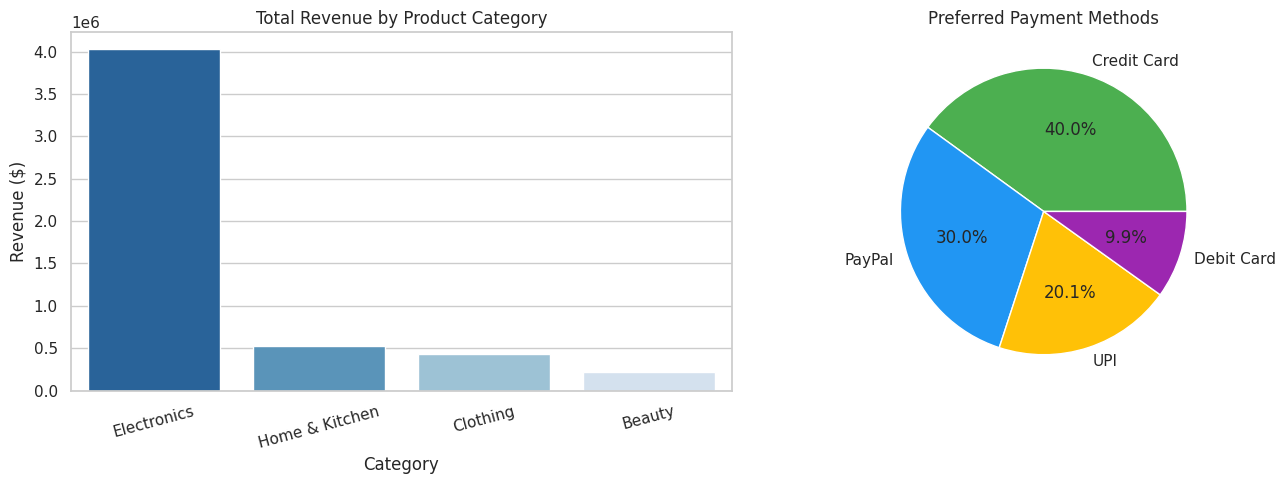

In [102]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
sns.set_theme(style="whitegrid")
plt.figure(figsize=(14, 5))

# Chart 1: Revenue by Category
plt.subplot(1, 2, 1)
cat_revenue = df.groupby('Category')['Total_Amount'].sum().sort_values(ascending=False).reset_index()
sns.barplot(data=cat_revenue, x='Category', y='Total_Amount', palette='Blues_r')
plt.title('Total Revenue by Product Category')
plt.ylabel('Revenue ($)')
plt.xticks(rotation=15)

# Chart 2: Payment Method Distribution
plt.subplot(1, 2, 2)
df['Payment_Method'].value_counts().plot(kind='pie', autopct='%1.1f%%', colors=['#4CAF50', '#2196F3', '#FFC107', '#9C27B0'])
plt.title('Preferred Payment Methods')
plt.ylabel('') # Hides the default vertical label

plt.tight_layout()
plt.show()


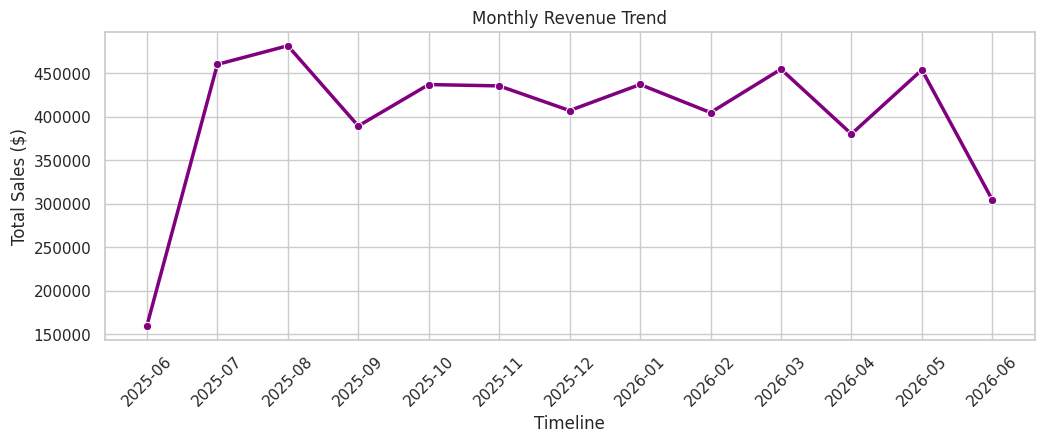

In [103]:
# Convert Date column to datetime format
df['Date'] = pd.to_datetime(df['Date'])

# Create a Year-Month column for grouping
df['Year_Month'] = df['Date'].dt.to_period('M')

# Calculate monthly revenue
monthly_revenue = df.groupby('Year_Month')['Total_Amount'].sum().reset_index()
monthly_revenue['Year_Month'] = monthly_revenue['Year_Month'].astype(str)

# Plot the trend line
plt.figure(figsize=(12, 4))
sns.lineplot(data=monthly_revenue, x='Year_Month', y='Total_Amount', marker='o', color='purple', linewidth=2.5)
plt.title('Monthly Revenue Trend')
plt.xlabel('Timeline')
plt.ylabel('Total Sales ($)')
plt.xticks(rotation=45)
plt.show()


In [104]:
# Ensure Date is in datetime format
df['Date'] = pd.to_datetime(df['Date'])

# Use the day after the last order in the dataset as the reference point
snapshot_date = df['Date'].max() + pd.Timedelta(days=1)

# Aggregate data by Customer_ID
rfm = df.groupby('Customer_ID').agg({
    'Date': lambda x: (snapshot_date - x.max()).days, # Recency
    'Order_ID': 'count',                             # Frequency
    'Total_Amount': 'sum'                            # Monetary
}).reset_index()

# Rename columns
rfm.columns = ['Customer_ID', 'Recency', 'Frequency', 'Monetary']

print("--- RFM Metrics Calculated ---")
print(rfm.head())


--- RFM Metrics Calculated ---
  Customer_ID  Recency  Frequency  Monetary
0   CUST-1000       14          6       584
1   CUST-1001       97          2       836
2   CUST-1002       59          7      1569
3   CUST-1003       60          2      1698
4   CUST-1004       21          6      3672


In [105]:
# Assign scores from 1 to 5
rfm['R_Score'] = pd.qcut(rfm['Recency'], 5, labels=[5, 4, 3, 2, 1])
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 5, labels=[1, 2, 3, 4, 5])
rfm['M_Score'] = pd.qcut(rfm['Monetary'], 5, labels=[1, 2, 3, 4, 5])

# Combine scores into a single RFM Score string
rfm['RFM_Cell'] = rfm['R_Score'].astype(str) + rfm['F_Score'].astype(str) + rfm['M_Score'].astype(str)

print("--- RFM Scores Assigned ---")
print(rfm[['Customer_ID', 'Recency', 'R_Score', 'Frequency', 'F_Score', 'Monetary', 'M_Score', 'RFM_Cell']].head())


--- RFM Scores Assigned ---
  Customer_ID  Recency R_Score  Frequency F_Score  Monetary M_Score RFM_Cell
0   CUST-1000       14       5          6       4       584       2      542
1   CUST-1001       97       2          2       1       836       3      213
2   CUST-1002       59       3          7       4      1569       4      344
3   CUST-1003       60       3          2       1      1698       4      314
4   CUST-1004       21       4          6       4      3672       5      445


In [106]:
def segment_customer(df_row):
    r = int(df_row['R_Score'])
    f = int(df_row['F_Score'])
    m = int(df_row['M_Score'])

    if r >= 4 and f >= 4 and m >= 4:
        return 'Champions (VIP)'
    elif r >= 3 and f >= 3:
        return 'Loyal Customers'
    elif r >= 4 and f <= 2:
        return 'Recent New Buyers'
    elif r <= 2 and f >= 3:
        return 'At Risk / Can\'t Lose Them'
    else:
        return 'Hibernating / Lost'

rfm['Segment'] = rfm.apply(segment_customer, axis=1)

# Count customers in each segment
segment_counts = rfm['Segment'].value_counts().reset_index()
print("--- Customer Segments Distribution ---")
print(segment_counts)


--- Customer Segments Distribution ---
                     Segment  count
0            Loyal Customers   1190
1         Hibernating / Lost   1188
2  At Risk / Can't Lose Them    669
3            Champions (VIP)    523
4          Recent New Buyers    401


/tmp/ipykernel_7905/1115640053.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=segment_counts, x='Segment', y='count', palette='viridis')


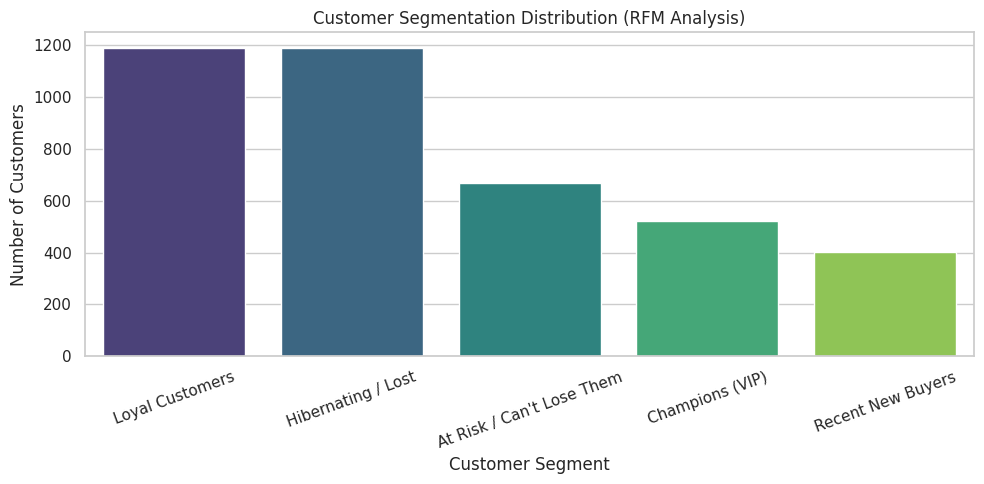

In [107]:
plt.figure(figsize=(10, 5))
sns.barplot(data=segment_counts, x='Segment', y='count', palette='viridis')
plt.title('Customer Segmentation Distribution (RFM Analysis)')
plt.xlabel('Customer Segment')
plt.ylabel('Number of Customers')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


In [108]:
import openpyxl
from openpyxl.styles import Font, Alignment, PatternFill, Border, Side
from openpyxl.utils import get_column_letter

# Ensure you have your final compiled dataframe ready
# (Combining original data with the RFM results from previous steps)
cleaned_dataset = pd.merge(df, rfm[['Customer_ID', 'Recency', 'Frequency', 'Monetary', 'Segment']], on='Customer_ID', how='left')


In [109]:
import sqlite3
import pandas as pd

# 1. Connect to an internal SQLite database file
conn = sqlite3.connect('ecommerce_project.db')

# Ensure 'Year_Month' column is in a SQLite-compatible format (e.g., string)
cleaned_dataset['Year_Month'] = cleaned_dataset['Year_Month'].astype(str)

# 2. Upload your fully processed dataframe into an SQL table named 'sales'
cleaned_dataset.to_sql('sales', conn, if_exists='replace', index=False)

print("Database 'ecommerce_project.db' established successfully!")
print("Table 'sales' populated with 20,000 transaction rows.")

Database 'ecommerce_project.db' established successfully!
Table 'sales' populated with 20,000 transaction rows.


In [110]:
# SQL Query for Core Business KPIs
query_kpis = """
SELECT
    COUNT(Order_ID) AS Total_Orders,
    SUM(Quantity) AS Total_Units_Sold,
    ROUND(SUM(Total_Amount), 2) AS Total_Revenue,
    ROUND(AVG(Total_Amount), 2) AS Average_Order_Value
FROM sales;
"""

print("--- STRATEGIC KPIs EXTRACED VIA SQL ---")
display(pd.read_sql_query(query_kpis, conn))


--- STRATEGIC KPIs EXTRACED VIA SQL ---


,Total_Orders,Total_Units_Sold,Total_Revenue,Average_Order_Value
0,20000,30637,5205606.0,260.28


In [111]:
# SQL Query for Category performance
query_categories = """
SELECT
    Category,
    COUNT(Order_ID) AS Total_Orders,
    ROUND(SUM(Total_Amount), 2) AS Category_Revenue,
    ROUND((SUM(Total_Amount) * 100.0 / (SELECT SUM(Total_Amount) FROM sales)), 2) AS Revenue_Contribution_Pct
FROM sales
GROUP BY Category
ORDER BY Category_Revenue DESC;
"""

# SQL Query for Payment popularity
query_payments = """
SELECT
    Payment_Method,
    COUNT(Order_ID) AS Total_Transactions,
    ROUND(SUM(Total_Amount), 2) AS Total_Volume_Value
FROM sales
GROUP BY Payment_Method
ORDER BY Total_Transactions DESC;
"""

print("--- PRODUCT VERTICAL SEGMENTATION (SQL) ---")
display(pd.read_sql_query(query_categories, conn))

print("\n--- PAYMENT CHANNEL DISTRIBUTION (SQL) ---")
display(pd.read_sql_query(query_payments, conn))


--- PRODUCT VERTICAL SEGMENTATION (SQL) ---


,Category,Total_Orders,Category_Revenue,Revenue_Contribution_Pct
0,Electronics,5986,4026258.0,77.34
1,Home & Kitchen,3952,530529.0,10.19
2,Clothing,6067,428031.0,8.22
3,Beauty,3995,220788.0,4.24



--- PAYMENT CHANNEL DISTRIBUTION (SQL) ---


,Payment_Method,Total_Transactions,Total_Volume_Value
0,Credit Card,8001,2112918.0
1,PayPal,5995,1495645.0
2,UPI,4028,1072165.0
3,Debit Card,1976,524878.0


In [112]:
# Advanced SQL: CTEs and Window Functions (NTILE)
query_advanced_rfm = """
WITH Calculated_RFM AS (
    SELECT
        Customer_ID,
        -- Calculate Recency: Days since the last transaction date
        CAST(JULIANDAY('2026-06-23') - JULIANDAY(MAX(Date)) AS INT) AS Recency,
        COUNT(Order_ID) AS Frequency,
        SUM(Total_Amount) AS Monetary
    FROM sales
    GROUP BY Customer_ID
),
Scored_RFM AS (
    SELECT
        Customer_ID,
        Recency, Frequency, Monetary,
        -- Use NTILE to split data into 5 equal groups (Quintiles)
        6 - NTILE(5) OVER (ORDER BY Recency) AS R_Score,
        NTILE(5) OVER (ORDER BY Frequency) AS F_Score,
        NTILE(5) OVER (ORDER BY Monetary) AS M_Score
    FROM Calculated_RFM
)
SELECT
    Customer_ID,
    Recency, Frequency, Monetary,
    R_Score, F_Score, M_Score,
    -- Use CASE WHEN to assign professional business labels
    CASE
        WHEN R_Score >= 4 AND F_Score >= 4 AND M_Score >= 4 THEN 'Champions (VIP)'
        WHEN R_Score >= 3 AND F_Score >= 3 THEN 'Loyal Customers'
        WHEN R_Score >= 4 AND F_Score <= 2 THEN 'Recent New Buyers'
        WHEN R_Score <= 2 AND F_Score >= 3 THEN 'At Risk / Can''t Lose Them'
        ELSE 'Hibernating / Lost'
    END AS Customer_Segment
FROM Scored_RFM
LIMIT 10;
"""

print("--- ADVANCED SQL: BEHAVIORAL SEGMENTATION MODEL ---")
display(pd.read_sql_query(query_advanced_rfm, conn))


--- ADVANCED SQL: BEHAVIORAL SEGMENTATION MODEL ---


,Customer_ID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,Customer_Segment
0,CUST-3964,0,2,113,5,1,1,Recent New Buyers
1,CUST-4799,0,2,1176,5,1,3,Recent New Buyers
2,CUST-2815,0,2,4154,5,1,5,Recent New Buyers
3,CUST-2362,0,3,297,5,1,1,Recent New Buyers
4,CUST-2968,0,3,1495,5,2,4,Recent New Buyers
5,CUST-3559,0,3,1746,5,2,4,Recent New Buyers
6,CUST-2458,0,4,302,5,2,1,Recent New Buyers
7,CUST-3386,0,4,541,5,2,2,Recent New Buyers
8,CUST-1304,0,4,874,5,2,3,Recent New Buyers
9,CUST-4996,0,4,1454,5,2,4,Recent New Buyers


In [113]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure theme settings are professional
sns.set_theme(style="whitegrid")

# Chart A: Top Categories by Revenue (Horizontal Bar Chart)
plt.figure(figsize=(4, 3.5))
cat_revenue = df.groupby('Category')['Total_Amount'].sum().sort_values(ascending=True).reset_index()
sns.barplot(data=cat_revenue, y='Category', x='Total_Amount', palette='Blues_r')
plt.title('Top Categories by Revenue', fontsize=10, fontweight='bold', pad=10)
plt.xlabel('')
plt.ylabel('Revenue')
plt.tight_layout()
plt.savefig('category_chart.png', dpi=150)
plt.close()

# Chart B: Monthly Revenue Trend (Line Chart)
plt.figure(figsize=(5, 3.5))
monthly_revenue = df.groupby('Year_Month')['Total_Amount'].sum().reset_index()
monthly_revenue['Year_Month'] = monthly_revenue['Year_Month'].astype(str)
sns.lineplot(data=monthly_revenue, x='Year_Month', y='Total_Amount', marker='o', color='#1F497D', linewidth=2)
plt.title('Monthly Revenue Trend', fontsize=12, fontweight='bold', pad=10)
plt.xlabel('Month')
plt.ylabel('Revenue')
plt.xticks(rotation=45, fontsize=8)
plt.tight_layout()
plt.savefig('trend_chart.png', dpi=150)
plt.close()

print("Charts successfully exported as local image assets!")


/tmp/ipykernel_7905/3070361103.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=cat_revenue, y='Category', x='Total_Amount', palette='Blues_r')


Charts successfully exported as local image assets!


In [114]:
import sqlite3
import openpyxl
from openpyxl.styles import Font, Alignment, PatternFill, Border, Side
from openpyxl.utils import get_column_letter
from openpyxl.drawing.image import Image

# Re-establish pipeline connections
conn = sqlite3.connect('ecommerce_project.db')
pipeline_df = pd.read_sql_query("SELECT * FROM sales;", conn)

wb = openpyxl.Workbook()
ws_summary = wb.active
ws_summary.title = "Summary"
ws_data = wb.create_sheet(title="E-Commerce Data")

# --- CORE TYPOGRAPHY & BRAND STYLING ---
font_dashboard_title = Font(name="Calibri", size=16, bold=True, color="1F497D")
font_sub_lbl = Font(name="Calibri", size=9, italic=True, color="595959")
font_card_lbl = Font(name="Calibri", size=9, color="595959", bold=True)
font_card_val = Font(name="Calibri", size=12, bold=True, color="000000")
font_table_hdr = Font(name="Calibri", size=10, bold=True, color="1F497D")
font_table_data = Font(name="Calibri", size=10, color="000000")

fill_light_gray = PatternFill(start_color="F2F5F8", end_color="F2F5F8", fill_type="solid")
fill_white = PatternFill(start_color="FFFFFF", end_color="FFFFFF", fill_type="solid")

thin_gray = Side(style='thin', color='D9D9D9')
card_border = Border(left=thin_gray, right=thin_gray, top=thin_gray, bottom=thin_gray)

# Ensure Gridlines stay visible
ws_summary.views.sheetView[0].showGridLines = True

# --- 1. TITLE BLOCK ARCHITECTURE ---
ws_summary["A1"] = "Ecommerce Executive Dashboard"
ws_summary["A1"].font = font_dashboard_title
ws_summary["A2"] = "A clean leadership-ready view of sales, customer mix, and revenue trends"
ws_summary["A2"].font = font_sub_lbl

# --- 2. PIPELINE CALCULATION COMPILING ---
total_orders = int(pipeline_df['Order_ID'].nunique())
unique_cust = int(pipeline_df['Customer_ID'].nunique())
total_revenue = float(pipeline_df['Total_Amount'].sum())
avg_order_val = float(pipeline_df['Total_Amount'].mean())

# Identify dynamic Top Segment and Top Category
top_segment = str(pipeline_df['Segment'].value_counts().index[0])
top_category = str(pipeline_df['Category'].value_counts().index[0])

# --- 3. CONSTRUCT UPPER METRICS CARD GRID ---
cards_config = [
    {"col_start": 1, "col_end": 2, "lbl": "Total Orders", "val": total_orders, "fmt": "#,##0"},
    {"col_start": 3, "col_end": 4, "lbl": "Unique Customers", "val": unique_cust, "fmt": "#,##0"},
    {"col_start": 5, "col_end": 6, "lbl": "Total Revenue", "val": total_revenue, "fmt": "$#,##0.00"},
    {"col_start": 7, "col_end": 8, "lbl": "Average Order Value", "val": avg_order_val, "fmt": "$#,##0.00"},
    {"col_start": 1, "col_end": 2, "lbl": "Top Segment", "val": top_segment, "fmt": "@", "row_offset": 4},
    {"col_start": 3, "col_end": 4, "lbl": "Top Category", "val": top_category, "fmt": "@", "row_offset": 4}
]

for card in cards_config:
    r_lbl = card.get("row_offset", 0) + 4
    r_val = card.get("row_offset", 0) + 5

    # Merge horizontal cells for cards
    ws_summary.merge_cells(start_row=r_lbl, start_column=card["col_start"], end_row=r_lbl, end_column=card["col_end"])
    ws_summary.merge_cells(start_row=r_val, start_column=card["col_start"], end_row=r_val, end_column=card["col_end"])

    lbl_cell = ws_summary.cell(row=r_lbl, column=card["col_start"])
    lbl_cell.value = card["lbl"]
    lbl_cell.font = font_card_lbl
    lbl_cell.fill = fill_light_gray
    lbl_cell.alignment = Alignment(horizontal="center", vertical="center")

    val_cell = ws_summary.cell(row=r_val, column=card["col_start"])
    val_cell.value = card["val"]
    val_cell.font = font_card_val
    val_cell.fill = fill_white
    val_cell.alignment = Alignment(horizontal="center", vertical="center")
    val_cell.number_format = card["fmt"]

    # Apply outer structural borders around target cells
    for r in [r_lbl, r_val]:
        for c in range(card["col_start"], card["col_end"] + 1):
            ws_summary.cell(row=r, column=c).border = card_border

# --- 4. CONSTRUCT LEFT TABULAR BREAKDOWNS ---
# Section A: Revenue by Category
ws_summary["A12"] = "Revenue by Category"
ws_summary["A12"].font = font_table_hdr

cat_data = pipeline_df.groupby('Category')['Total_Amount'].sum().sort_values(ascending=False).reset_index()
for i, row in enumerate(cat_data.itertuples(), 13):
    ws_summary[f"A{i}"] = row.Category
    ws_summary[f"B{i}"] = row.Total_Amount
    ws_summary[f"A{i}"].font = font_table_data
    ws_summary[f"B{i}"].font = font_table_data
    ws_summary[f"B{i}"].number_format = '$#,##0.00'

# Section B: Revenue Trend by Month
ws_summary["A20"] = "Revenue Trend by Month"
ws_summary["A20"].font = font_table_hdr

month_data = pipeline_df.groupby('Year_Month')['Total_Amount'].sum().reset_index()
for i, row in enumerate(month_data.itertuples(), 21):
    ws_summary[f"A{i}"] = str(row.Year_Month)
    ws_summary[f"B{i}"] = row.Total_Amount
    ws_summary[f"A{i}"].font = font_table_data
    ws_summary[f"B{i}"].font = font_table_data
    ws_summary[f"B{i}"].number_format = '$#,##0.00'

# --- 5. EMBED MATCHING PLOT IMAGES ACCORDING TO IMAGE MAP ---
try:
    img_cat = Image('category_chart.png')
    ws_summary.add_image(img_cat, 'D12')  # Placed directly next to Category Table

    img_trend = Image('trend_chart.png')
    ws_summary.add_image(img_trend, 'I12')  # Placed right beside the Category Plot
except Exception as e:
    print(f"Image scaling attachment skip check: {e}")

# --- 6. POPULATE STANDARDIZED DATA SHEET ---
ws_data.append(list(pipeline_df.columns))
for row in pipeline_df.itertuples(index=False):
    ws_data.append(list(row))

# Adjust data width spacing auto-rules
for col in ws_summary.columns:
    col_letter = get_column_letter(col[0].column)
    ws_summary.column_dimensions[col_letter].width = 14

output_filename = "ecommerce_data_dashboard.xlsx"
wb.save(output_filename)
conn.close()

print(f"Perfect Dashboard successfully outputted as '{output_filename}'!")

Perfect Dashboard successfully outputted as 'ecommerce_data_dashboard.xlsx'!


In [117]:
from google.colab import files
files.download('ecommerce_data_dashboard.xlsx')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Executive Summary: Advanced E-Commerce Performance & Customer Segmentation Report
1. Key Performance Indicators (KPIs)
Total Sales Revenue:  5,205,606.00
TotalVolumeSold:30637units
AverageOrderValue(AOV): 260.28 per transaction
2. Strategic Insights & Data Findings
Product & Timeline Trends
Dominant Category: The Electronics category drives the highest revenue, contributing  4,026,258.
tototalsales led specifically by sales of Laptops and Smartphones.ConsumerPaymentHabits:CreditCards are the preferred choice for checkouts,accounting for roughly40.
SeasonalityTrends:Sales revenue experienced adistinct spike during August 2025( 481,737.00), highlighting a crucial seasonal purchasing pattern.
Advanced Customer Behavior (RFM Segmentation)
High-Value VIPs: Our Champions (VIP) segment contains 523 customers, who are our most valuable users buying frequently and spending the highest amounts. They represent the core financial health of our store.
Retention Alert: The At Risk / Can't Lose Them segment consists of 669 historically high-spending customers who have not made a purchase recently. They are at risk of churning completely.
Dormant Base: The Hibernating / Lost segment represents 1188 customers, a significant portion of users with low recency and frequency scores, requiring low-cost re-engagement methods.
3. Data-Driven Recommendations
VIP Loyalty Program: Launch an exclusive early-access rewards program tailored specifically for the Champions (VIP) segment to maximize their lifetime value.
Win-Back Email Campaigns: Deploy targeted email discounts and personalized product recommendations to the At Risk customer segment to incentivize their next purchase before they churn.
Cross-Category Bundling: Introduce promotional product bundles (e.g., pairing Wireless Headphones with Laptops) during low-sales months to increase the Average Order Value across all segments.

In [116]:
# Merge the clean RFM data back with the main e-commerce dataframe
cleaned_dataset = pd.merge(df, rfm[['Customer_ID', 'Recency', 'Frequency', 'Monetary', 'Segment']], on='Customer_ID', how='left')

# Export the fully compiled, cleaned dataset to a new CSV file
cleaned_dataset.to_csv('cleaned_ecommerce_data.csv', index=False)

# Trigger an immediate browser download of the file
from google.colab import files
files.download('cleaned_ecommerce_data.csv')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>